# Fixing SWDOWN
Getting rid of nightime data because the irradiance is 0 and therefore not relevant and skews the data

In [26]:
import xarray as xr
import numpy as np
import scipy as sp
import netCDF4 as nc
import os
import shutil
import csv
import pandas as pd
import torch_dl4ds as dds
import torch as pt
import matplotlib.pyplot as plt

In [27]:
uwrf_train = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_train.nc')
uwrf_val = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_val.nc')
uwrf_test = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_test.nc')
# --------
nam_train = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_train.nc')
nam_val = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_val.nc')
nam_test = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_test.nc')

In [50]:
nam = nam_train['SWDOWN']
uwrf = uwrf_train['SWDOWN']

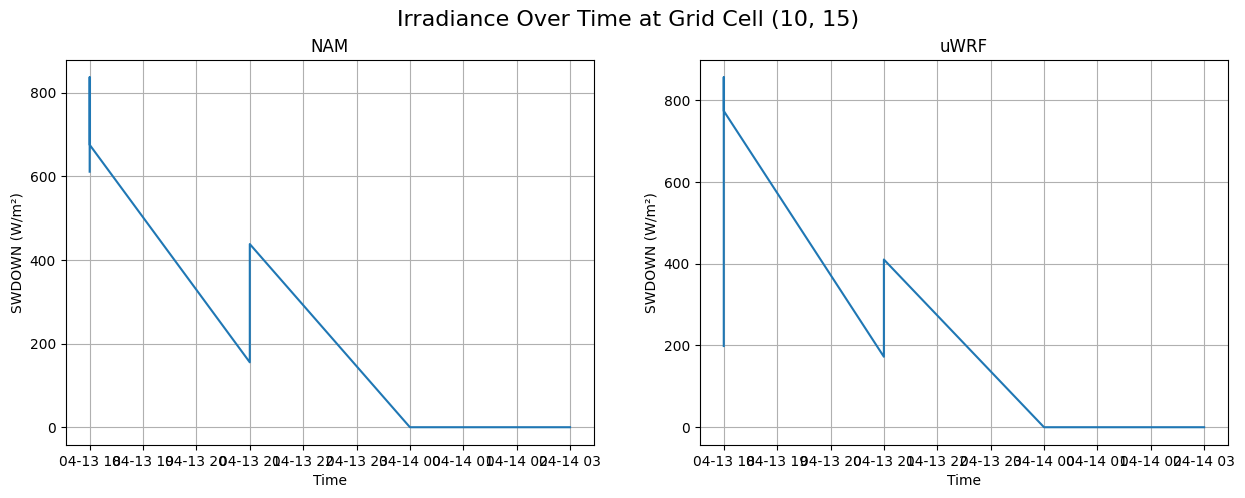

In [98]:
import matplotlib.pyplot as plt

# Example: select a specific grid cell (using index)
x_idx, y_idx = 10, 15 
plt.figure(figsize=(15, 5)) 
ghi_point = nam.isel(x=x_idx, y=y_idx)
ghi_time_series = ghi_point.values

idx = -12

plt.subplot(1, 2, 1)
ghi_point = nam.isel(x=x_idx, y=y_idx)  
ghi_time_series = ghi_point.values
plt.plot(nam.time[idx:], ghi_time_series[idx:])
plt.title(f'NAM')
plt.xlabel('Time')
plt.ylabel('SWDOWN (W/m²)')
plt.grid(True)
#--------------
plt.subplot(1, 2, 2)
ghi_point = uwrf.isel(x=x_idx, y=y_idx)
ghi_time_series = ghi_point.values
plt.plot(uwrf.time[idx:], ghi_time_series[idx:])
plt.title(f'uWRF')
plt.xlabel('Time')
plt.ylabel('SWDOWN (W/m²)')
plt.grid(True)

plt.suptitle(f'Irradiance Over Time at Grid Cell ({x_idx}, {y_idx})', fontsize=16)

plt.show()


In [79]:
print(nam.time[:idx])



<xarray.DataArray 'time' (time: 15)> Size: 120B
array(['2019-01-01T00:00:00.000000000', '2019-01-01T03:00:00.000000000',
       '2019-01-01T06:00:00.000000000', '2019-01-01T09:00:00.000000000',
       '2019-01-01T12:00:00.000000000', '2019-01-01T15:00:00.000000000',
       '2019-01-01T18:00:00.000000000', '2019-01-01T21:00:00.000000000',
       '2019-01-02T00:00:00.000000000', '2019-01-02T03:00:00.000000000',
       '2019-01-02T03:00:00.000000000', '2019-01-02T06:00:00.000000000',
       '2019-01-02T09:00:00.000000000', '2019-01-02T12:00:00.000000000',
       '2019-01-02T15:00:00.000000000'], dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 120B 2019-01-01 ... 2019-01-02T15:00:00
Attributes:
    long_name:                   verification time generated by wgrib2 functi...
    reference_time:              1546387200.0
    reference_time_type:         3
    reference_date:              2019.01.02 00:00:00 UTC
    reference_time_description:  forecast or accumulated,

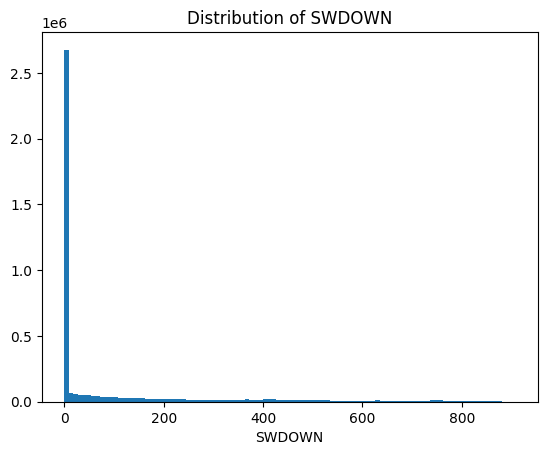

In [80]:
vals = og.values.flatten()
plt.hist(vals, bins=100)
plt.title(f'Distribution of SWDOWN')
plt.xlabel(f'SWDOWN')
plt.show()

# Filtering for the daytime hours
The time steps that are representative of daytime hours are 15, 18, 21 UTC. 

In [30]:
ds = uwrf_train['SWDOWN'].sel(time=uwrf_train.time.dt.hour.isin([15, 18, 21]))


In [35]:
ds

<xarray.DataArray 'SWDOWN' (time: 835, y: 120, x: 120)> Size: 48MB
[12024000 values with dtype=float32]
Coordinates:
    latitude   (time, y, x) float32 48MB ...
    longitude  (time, y, x) float32 48MB ...
  * time       (time) datetime64[ns] 7kB 2019-01-01T15:00:00 ... 2019-04-13T2...
Dimensions without coordinates: y, x
Attributes:
    FieldType:    104
    MemoryOrder:  XY 
    description:  DOWNWARD SHORT WAVE FLUX AT GROUND SURFACE
    units:        W m-2
    stagger:

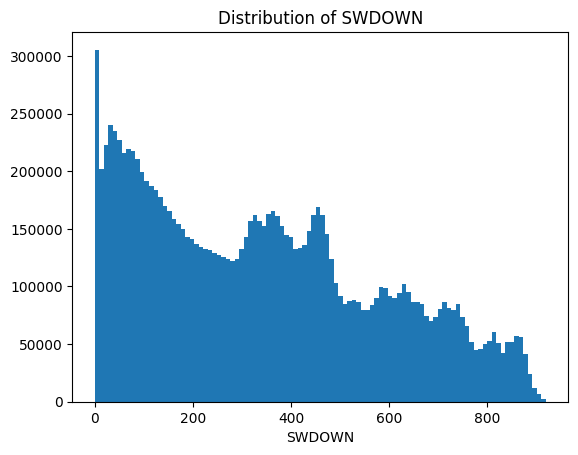

In [81]:
vals = ds.values.flatten()
plt.hist(vals, bins=100)
plt.title(f'Distribution of SWDOWN')
plt.xlabel(f'SWDOWN')
plt.show()

In [99]:
nam_day = nam_train['SWDOWN'].sel(time=nam_train.time.dt.hour.isin([15, 18, 21]))

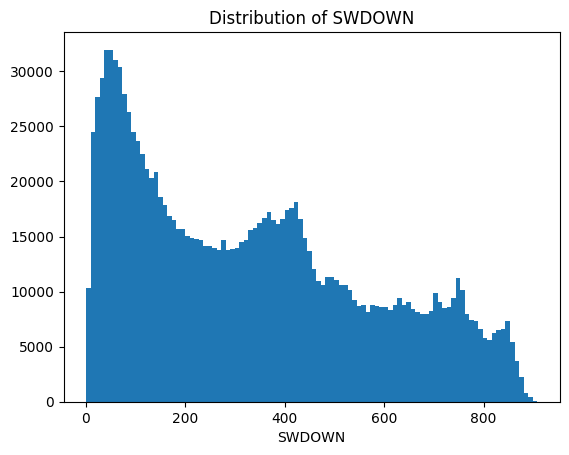

In [102]:
vals = nam_day.values.flatten()
plt.hist(vals, bins=100)
plt.title(f'Distribution of SWDOWN')
plt.xlabel(f'SWDOWN')
plt.show()

In [89]:
import numpy as np

vals = ds.values.flatten()

near_zero_count = np.sum((vals >= 0) & (vals <= 10))


print(f"Count of values near 0: {near_zero_count}")


Count of values near 0: 322399


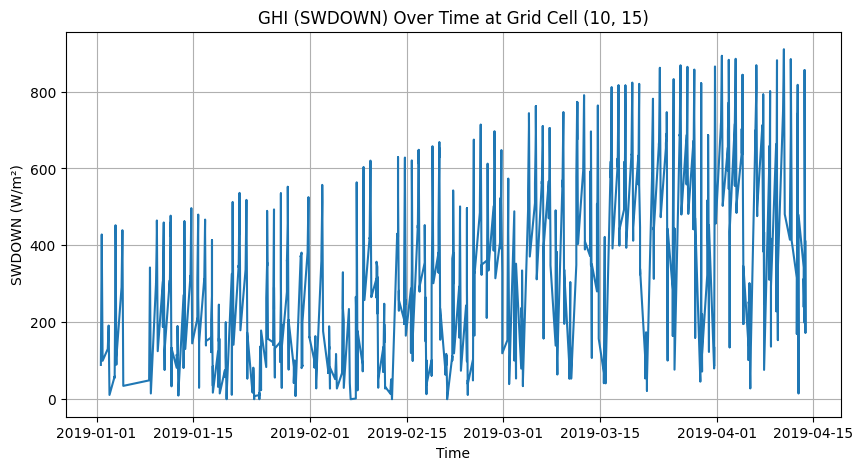

In [39]:
import matplotlib.pyplot as plt

# Example: select a specific grid cell (using index)
x_idx, y_idx = 10, 15  # change indices to your desired location

ghi_point = ds.isel(x=x_idx, y=y_idx)  # Select that grid cell
ghi_time_series = ghi_point.values  # Extract values over time

# Plot over time
plt.figure(figsize=(10, 5))
plt.plot(ds.time, ghi_time_series)
plt.title(f'GHI (SWDOWN) Over Time at Grid Cell ({x_idx}, {y_idx})')
plt.xlabel('Time')
plt.ylabel('SWDOWN (W/m²)')
plt.grid(True)
plt.show()


In [25]:
ds.where(ds != 0, drop=True)

<xarray.DataArray 'SWDOWN' (time: 835, y: 120, x: 120)> Size: 48MB
array([[[ 84.728    ,  85.508804 ,  86.18639  , ...,  23.71654  ,
          24.79862  ,  25.744526 ],
        [ 85.06444  ,  85.93893  ,  86.64372  , ...,  22.343266 ,
          23.634218 ,  24.64979  ],
        [ 85.69672  ,  86.435455 ,  87.07443  , ...,  18.725494 ,
          20.336302 ,  20.524427 ],
        ...,
        [ 54.69206  ,  43.566322 ,  34.60879  , ..., 291.45554  ,
         293.65814  , 267.07303  ],
        [ 49.318714 ,  41.362053 ,  33.611874 , ..., 292.8184   ,
         293.50546  , 280.5874   ],
        [ 45.254654 ,  40.139996 ,  33.256172 , ..., 291.5726   ,
         291.7139   , 288.60144  ]],

       [[389.50882  , 383.6447   , 375.87268  , ..., 136.85863  ,
         130.89606  , 125.31268  ],
        [399.88327  , 394.14008  , 387.27982  , ..., 147.87726  ,
         141.84628  , 137.26572  ],
        [405.8286   , 399.61206  , 396.10858  , ..., 162.54944  ,
         154.49889  , 150.33623  ],
...
        [386.91486  , 388.64297  , 390.53656  , ..., 436.7585   ,
         439.82092  , 439.3305   ],
        [386.49966  , 387.40894  , 388.37015  , ..., 430.74182  ,
         439.00375  , 439.00607  ],
        [390.51968  , 389.56274  , 389.64725  , ..., 413.9142   ,
         435.52148  , 438.73325  ]],

       [[328.35516  , 320.75943  , 315.26306  , ...,   3.01456  ,
           2.490275 ,   2.1286914],
        [339.95126  , 330.4205   , 322.23904  , ...,   3.5934982,
           2.7376766,   2.4760494],
        [352.738    , 342.21973  , 331.9677   , ...,   4.605303 ,
           3.3706386,   3.0836382],
        ...,
        [216.1292   , 217.88338  , 221.67851  , ..., 353.2219   ,
         345.6508   , 333.85373  ],
        [213.54942  , 213.45125  , 214.31636  , ..., 360.35938  ,
         355.3431   , 340.47772  ],
        [216.48732  , 213.05272  , 212.63768  , ..., 351.59094  ,
         349.10464  , 353.44522  ]]], shape=(835, 120, 120), dtype=float32)
Coordinates:
    latitude   (time, y, x) float32 48MB 39.84 39.83 39.82 ... 42.04 42.03 42.02
    longitude  (time, y, x) float32 48MB -76.7 -76.67 -76.64 ... -71.25 -71.22
  * time       (time) datetime64[ns] 7kB 2019-01-01T15:00:00 ... 2019-04-13T2...
Dimensions without coordinates: y, x
Attributes:
    FieldType:    104
    MemoryOrder:  XY 
    description:  DOWNWARD SHORT WAVE FLUX AT GROUND SURFACE
    units:        W m-2
    stagger:

In [11]:
night = uwrf_train['SWDOWN'].sel(time=~uwrf_train.time.dt.hour.isin([15, 18, 21]))

In [18]:
night

<xarray.DataArray 'SWDOWN' (time: 1862, y: 120, x: 120)> Size: 107MB
array([[[0., 0., ..., 0., 0.],
        [0., 0., ..., 0., 0.],
        ...,
        [0., 0., ..., 0., 0.],
        [0., 0., ..., 0., 0.]],

       [[0., 0., ..., 0., 0.],
        [0., 0., ..., 0., 0.],
        ...,
        [0., 0., ..., 0., 0.],
        [0., 0., ..., 0., 0.]],

       ...,

       [[0., 0., ..., 0., 0.],
        [0., 0., ..., 0., 0.],
        ...,
        [0., 0., ..., 0., 0.],
        [0., 0., ..., 0., 0.]],

       [[0., 0., ..., 0., 0.],
        [0., 0., ..., 0., 0.],
        ...,
        [0., 0., ..., 0., 0.],
        [0., 0., ..., 0., 0.]]], shape=(1862, 120, 120), dtype=float32)
Coordinates:
    latitude   (time, y, x) float32 107MB ...
    longitude  (time, y, x) float32 107MB ...
  * time       (time) datetime64[ns] 15kB 2019-01-01 ... 2019-04-14T03:00:00
Dimensions without coordinates: y, x
Attributes:
    FieldType:    104
    MemoryOrder:  XY 
    description:  DOWNWARD SHORT WAVE FLUX AT GROUND SURFACE
    units:        W m-2
    stagger:

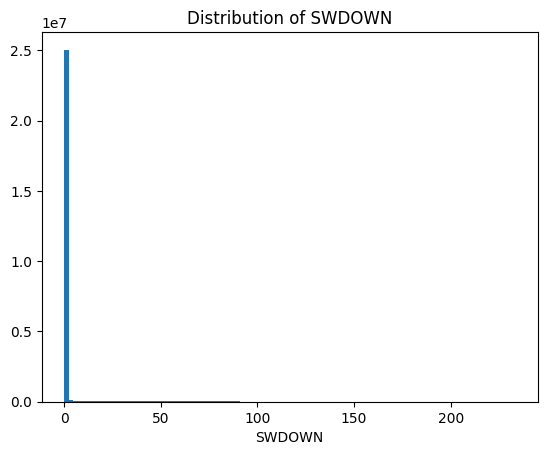

In [12]:
vals = night.values.flatten()
plt.hist(vals, bins=100)
plt.title(f'Distribution of SWDOWN')
plt.xlabel(f'SWDOWN')
plt.show()

In [21]:
night.values == 0

array([[[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        ...,
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True]],

       [[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        ...,
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True]],

       [[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        ...,
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  Tr

In [22]:
non_zero_values = night.where(night != 0, drop=True)


In [23]:
non_zero_values

<xarray.DataArray 'SWDOWN' (time: 219, y: 120, x: 120)> Size: 13MB
array([[[           nan,            nan,            nan, ...,
                    nan,            nan, 9.99999972e-10],
        [           nan,            nan,            nan, ...,
                    nan,            nan, 9.99999972e-10],
        [           nan,            nan,            nan, ...,
                    nan,            nan, 9.99999972e-10],
        ...,
        [           nan,            nan,            nan, ...,
         9.99999972e-10, 9.99999972e-10, 9.99999972e-10],
        [           nan,            nan,            nan, ...,
         9.99999972e-10, 9.99999972e-10, 9.99999972e-10],
        [           nan,            nan,            nan, ...,
         9.99999972e-10, 9.99999972e-10, 9.99999972e-10]],

       [[           nan,            nan,            nan, ...,
                    nan,            nan, 9.99999972e-10],
        [           nan,            nan,            nan, ...,
                    nan,            nan, 9.99999972e-10],
        [           nan,            nan,            nan, ...,
                    nan,            nan, 9.99999972e-10],
...
         6.31182432e+00, 8.80793476e+00, 1.12381392e+01],
        [6.38474846e+01, 6.58835449e+01, 6.82392578e+01, ...,
         1.19677143e+01, 1.26631651e+01, 1.29082956e+01],
        [6.26718636e+01, 6.46584625e+01, 6.71668091e+01, ...,
         1.53528261e+01, 1.45654831e+01, 1.38958063e+01]],

       [[5.64351678e-01, 7.25210428e-01, 2.31817174e+00, ...,
         6.09225121e+01, 6.24917336e+01, 6.38840370e+01],
        [2.83297628e-01, 1.02627628e-01, 2.13509274e+00, ...,
         6.08319817e+01, 6.26310616e+01, 6.39884911e+01],
        [1.86089873e-01, 9.99999972e-10, 9.64357853e-01, ...,
         6.08286514e+01, 6.26591034e+01, 6.38720055e+01],
        ...,
        [5.00677376e+01, 5.63441620e+01, 6.26868782e+01, ...,
         2.67003417e+00, 2.10749578e+00, 4.92827624e-01],
        [4.60530472e+01, 5.11050377e+01, 5.72200279e+01, ...,
         3.51125693e+00, 3.34810090e+00, 8.40826869e-01],
        [4.29185677e+01, 4.68232956e+01, 5.20757904e+01, ...,
         3.27090716e+00, 3.09354281e+00, 1.40783930e+00]]],
      shape=(219, 120, 120), dtype=float32)
Coordinates:
    latitude   (time, y, x) float32 13MB 39.84 39.83 39.82 ... 42.04 42.03 42.02
    longitude  (time, y, x) float32 13MB -76.7 -76.67 -76.64 ... -71.25 -71.22
  * time       (time) datetime64[ns] 2kB 2019-02-17T12:00:00 ... 2019-04-13T1...
Dimensions without coordinates: y, x
Attributes:
    FieldType:    104
    MemoryOrder:  XY 
    description:  DOWNWARD SHORT WAVE FLUX AT GROUND SURFACE
    units:        W m-2
    stagger: